In [ ]:
!pip install pennylane --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 112.1 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import math as m
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


# Función constante o balanceada, solución clásica.

In [ ]:
def caja_negra_f():
    # Devuelve una de las cuatro posibles funciones f
    def F1(x):
        return 0

    def F2(x):
        return 1

    def F3(x):
        return x % 2

    def F4(x):
        return (x + 1) % 2

    funciones = [F1, F2, F3, F4]
    f = funciones[int(m.floor(4 * np.random.rand()))]
    return f

F = caja_negra_f()

print('f(0): ', F(0))
print('f(1): ', F(1))

if (F(0) == F(1)):
    print('Conclusión: f es constante!')
else:
    print('Conclusión: f es balanceada!')

f(0):  0
f(1):  0
Conclusión: f es constante!


# Implementación de caja negra (black box)

In [ ]:
# Dispositivo de 2 qubits
dev = qml.device("default.qubit", wires=2)

def estado_inicial():
    # Genero el estado (|00> - |10>)/sqrt(2)
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.CZ(wires=[0, 1])
    qml.PauliX(wires=1)

def aplicar_oraculo(tipo):
    # Caja negra: dos funciones constantes y dos balanceadas
    if tipo == "const_0":          # f(x) = 0
        pass
    elif tipo == "const_1":        # f(x) = 1
        qml.PauliX(wires=1)
    elif tipo == "bal_0":          # f(x) = x
        qml.CNOT(wires=[0, 1])
    elif tipo == "bal_1":          # f(x) = 1 - x
        qml.PauliX(wires=0)
        qml.CNOT(wires=[0, 1])
        qml.PauliX(wires=0)

@qml.qnode(dev)
def circuito_inicial():
    estado_inicial()
    return qml.state()

@qml.qnode(dev)
def circuito_con_caja_negra(tipo):
    estado_inicial()
    aplicar_oraculo(tipo)
    return qml.state()

In [ ]:
# Elegimos aleatoriamente una de las cuatro funciones de la caja negra.
tipos = ["const_0", "const_1", "bal_0", "bal_1"]
idx = np.random.randint(0, 4)
tipo_elegido = tipos[idx]

print("Estado inicial")
print(circuito_inicial())

print("\n Tipo de función elegida (caja negra):", tipo_elegido)

print("\n Después de la caja negra")
print(circuito_con_caja_negra(tipo_elegido))

___ Estado inicial ___
[ 0.70710678+0.j  0.        +0.j -0.70710678+0.j  0.        +0.j]

Tipo de función elegida (caja negra): bal_0

___ Después de la caja negra ___
[ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]


## Primera etapa de algoritmo de Deutsch (registro auxiliar $|1\rangle$)

___ Estado después de la etapa 1 (Deutsch) ___
[ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]

___ Circuito ___
(<Figure size 500x300 with 1 Axes>, <Axes: >)


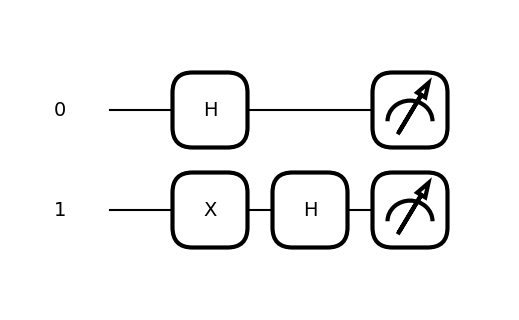

In [ ]:
# Dispositivo de 2 qubits
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def deutsch_etapa_1():
    # Superposición del qubit de entrada y el ancilla en |->
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)
    return qml.state()

estado = deutsch_etapa_1()

print("___ Estado después de la etapa 1 (Deutsch) ___")
print(estado)

# Dibujo del circuito
print("\n___ Circuito ___")
print(qml.draw_mpl(deutsch_etapa_1)())

## Algoritmo de Deutsch completo (generador de funciones "black box" integrado)

In [ ]:
# Dispositivo de 2 qubits
dev = qml.device("default.qubit", wires=2)

def aplicar_oraculo(tipo):
    # Caja negra: dos funciones constantes y dos balanceadas (Deutsch)
    if tipo == "const_0":          # f(x) = 0
        pass
    elif tipo == "const_1":        # f(x) = 1
        qml.PauliX(wires=1)
    elif tipo == "bal_0":          # f(x) = x
        qml.CNOT(wires=[0, 1])
    elif tipo == "bal_1":          # f(x) = 1 - x
        qml.PauliX(wires=0)
        qml.CNOT(wires=[0, 1])
        qml.PauliX(wires=0)

@qml.qnode(dev)
def deutsch_estado_inicial():
    # Primera etapa: |+> en el qubit 0 y |-> en el qubit 1
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)
    return qml.state()

@qml.qnode(dev)
def deutsch_despues_caja_negra(tipo):
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)

    aplicar_oraculo(tipo)
    return qml.state()

@qml.qnode(dev)
def deutsch_despues_h2(tipo):
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)
    aplicar_oraculo(tipo) ### Oraculo
    # Etapa final: H^{\otimes 2}
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    return qml.state()

# Elegimos aleatoriamente una función para la caja negra
tipos = ["const_0", "const_1", "bal_0", "bal_1"]
tipo_elegido = tipos[int(np.random.randint(0, 4))]

print("___ Estado inicial ___")
print(deutsch_estado_inicial())

print("\nTipo de función elegida (caja negra):", tipo_elegido)

print("\n___ Después de la caja negra ___")
print(deutsch_despues_caja_negra(tipo_elegido))

print("\n___ Después de H^2 ___")
print(deutsch_despues_h2(tipo_elegido))

___ Estado inicial ___
[ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]

Tipo de función elegida (caja negra): bal_1

___ Después de la caja negra ___
[-0.5+0.j  0.5+0.j  0.5+0.j -0.5+0.j]

___ Después de H^2 ___
[ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]



___ Circuito cuántico final ___
(<Figure size 1100x300 with 1 Axes>, <Axes: >)


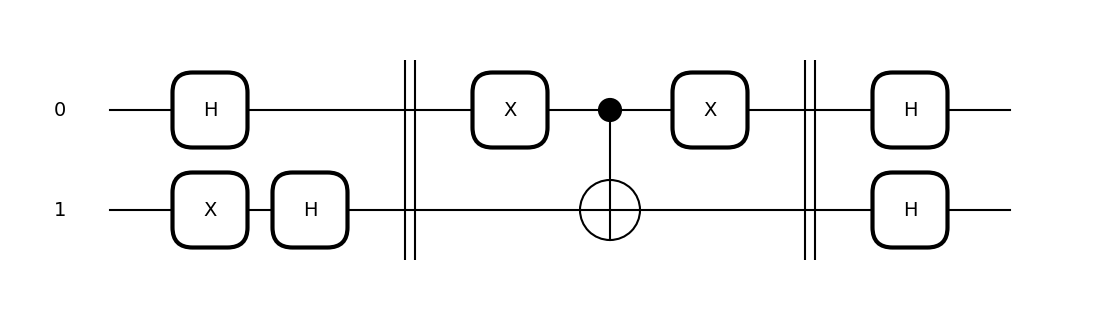

In [ ]:
### Dibujar circuito final ###
def deutsch_circuito(tipo):
    qml.Hadamard(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=1)
    qml.Barrier(wires=[0,1])
    aplicar_oraculo(tipo)
    qml.Barrier(wires=[0,1])
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)

@qml.qnode(dev)
def deutsch_despues_h2(tipo):
    deutsch_circuito(tipo)
    return qml.state()

print("\n___ Circuito cuántico final ___")
print(qml.draw_mpl(deutsch_circuito)(tipo_elegido))